**Retina net**

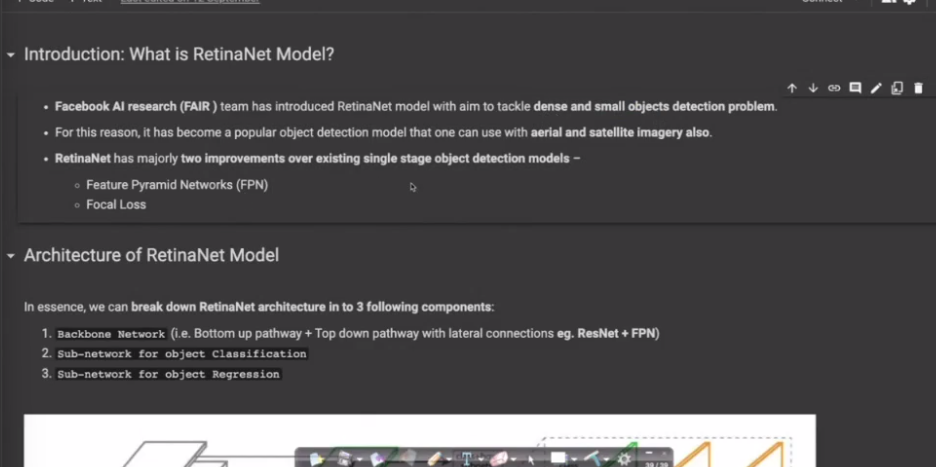

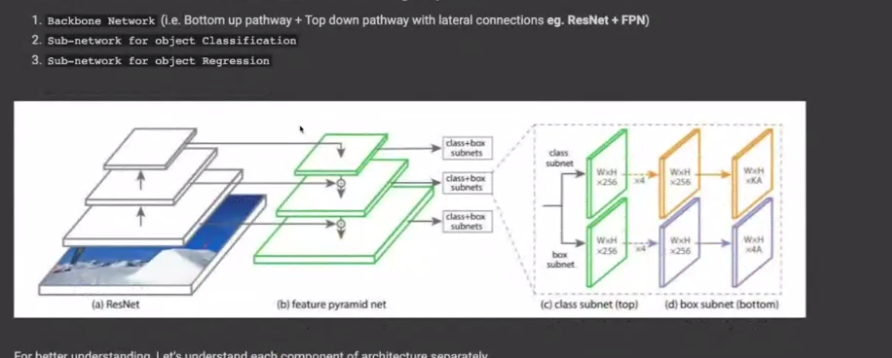

## RetinaNet Model in Computer Vision

RetinaNet is a state-of-the-art single-stage object detection model designed to achieve both high accuracy and efficiency. It was introduced by Facebook AI Research (FAIR) in 2017 to address the long-standing problem of class imbalance during training in object detection tasks, particularly in the presence of a large number of easy background examples.

### Key Components of RetinaNet:

1.  **Feature Pyramid Network (FPN)**: RetinaNet employs an FPN as its backbone for extracting features at multiple scales. FPN helps detect objects of various sizes by building a top-down pathway with lateral connections, allowing high-level semantic features to be combined with low-level detailed features.

2.  **Focal Loss**: This is the most significant contribution of RetinaNet. Focal Loss is a modified cross-entropy loss that down-weights the loss assigned to well-classified examples (easy negatives) during training. This prevents the vast number of easy negatives from overwhelming the training process and enables the model to focus more on hard, misclassified examples. This is crucial for single-stage detectors like RetinaNet, which struggle with class imbalance more than two-stage detectors.

3.  **Two Task-Specific Subnets**: RetinaNet uses two separate subnets attached to the FPN for object classification and bounding box regression:
    *   **Classification Subnet**: A small Fully Convolutional Network (FCN) that predicts the probability of an object being present at each spatial location for each of the K object classes.
    *   **Box Regression Subnet**: Another small FCN that predicts the offset from each anchor box to a nearby ground-truth object for each of the K object classes.

### RetinaNet Architecture Overview:

*   **Backbone**: Typically ResNet with FPN. The ResNet extracts rich semantic information, and the FPN then builds a multi-scale feature pyramid on top of it.
*   **Anchor Boxes**: RetinaNet uses a set of predefined anchor boxes at each spatial location and at various scales and aspect ratios to cover a wide range of object shapes and sizes.
*   **Loss Function**: The total loss is a sum of the Focal Loss for classification and a smooth L1 loss for bounding box regression.

### Advantages of RetinaNet:

*   **Addresses Class Imbalance**: Focal Loss effectively handles the imbalance between foreground and background classes, which is a common challenge in object detection.
*   **High Accuracy**: It achieves competitive accuracy with two-stage detectors while maintaining the speed of single-stage detectors.
*   **Efficiency**: Being a single-stage detector, it is generally faster than two-stage detectors like Faster R-CNN.
*   **Simplicity**: Its architecture is relatively straightforward compared to some other complex detection models.

RetinaNet has been influential in the development of subsequent object detection models and remains a strong baseline for many tasks.

**Object Segmentation**

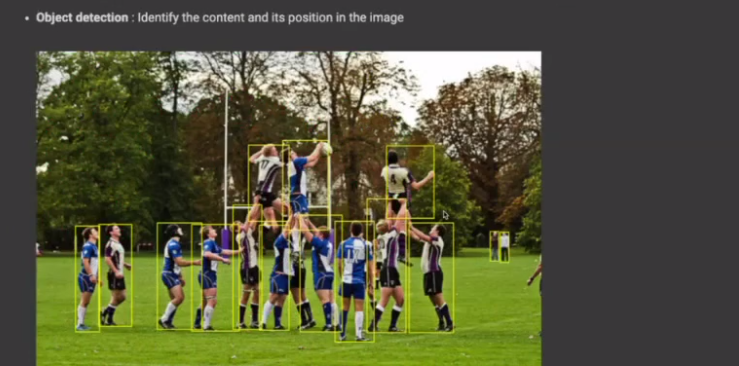

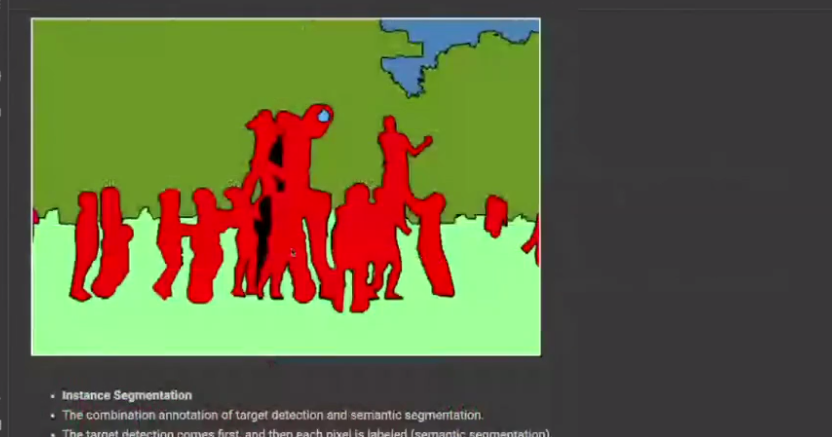

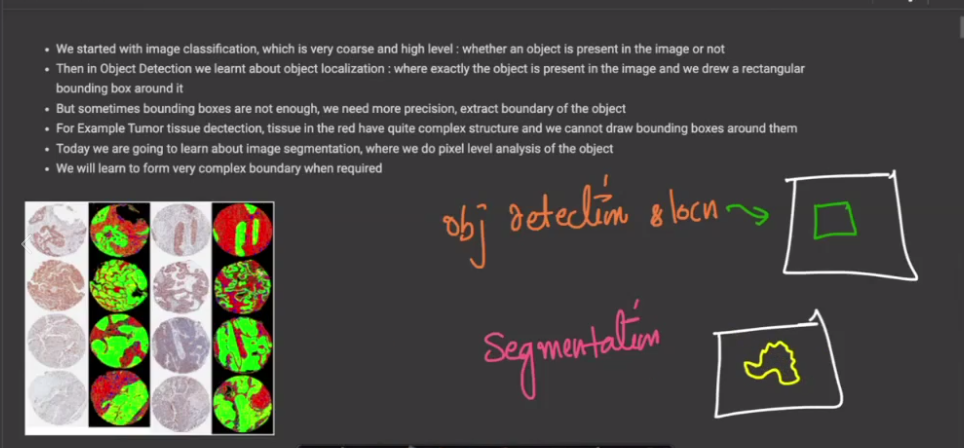

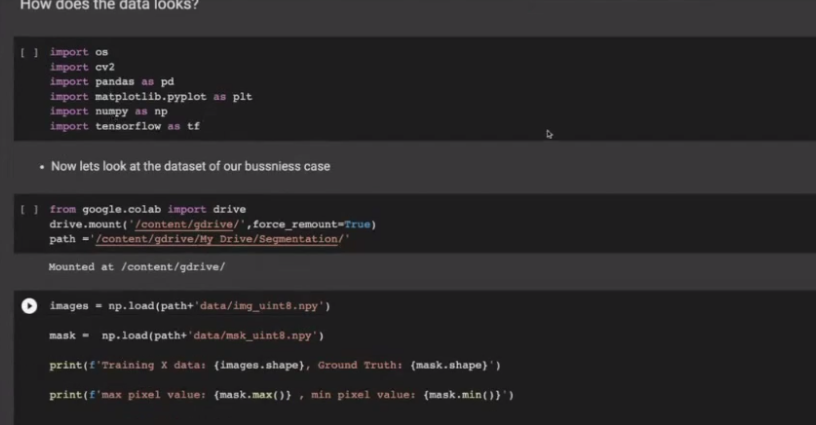

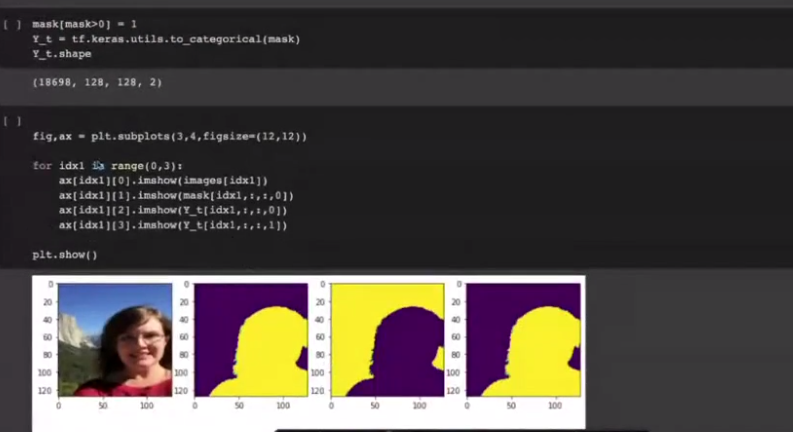

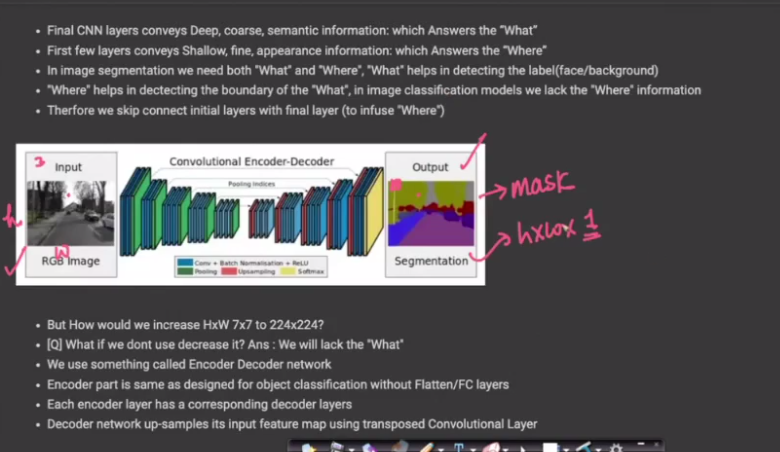

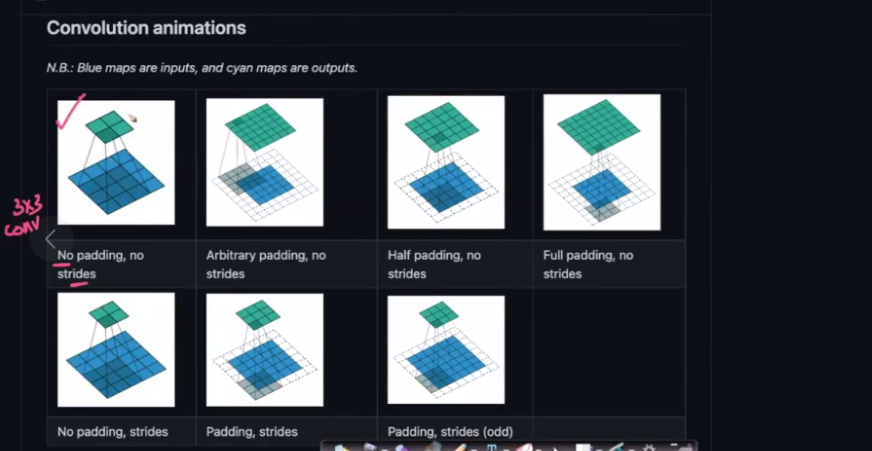

read here in read.me file -  https://github.com/vdumoulin/conv_arithmetic

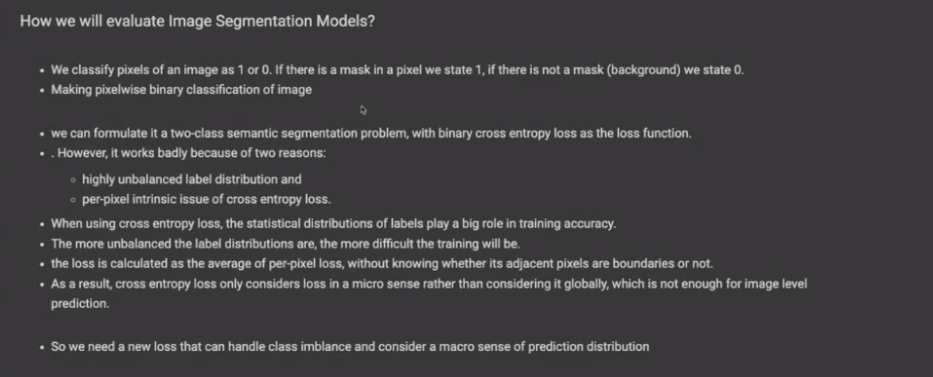

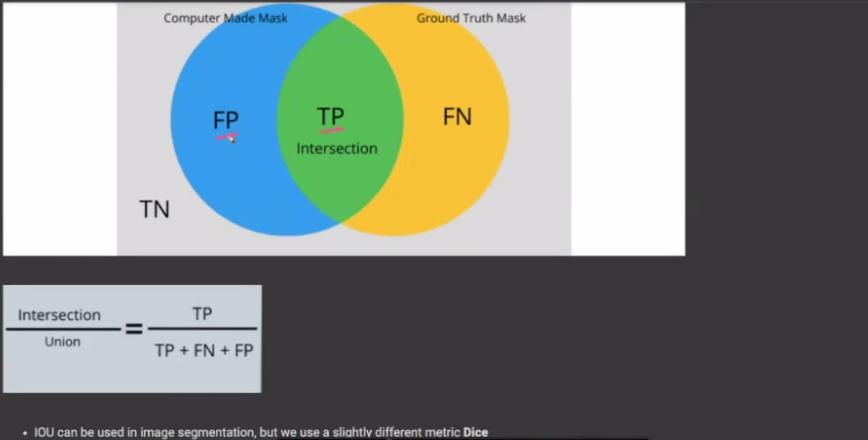

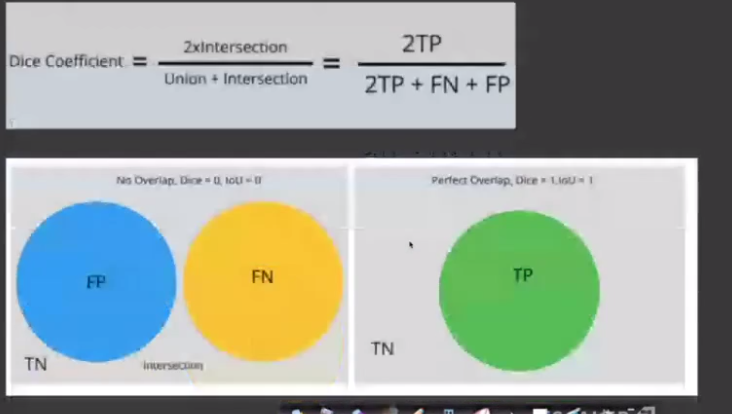

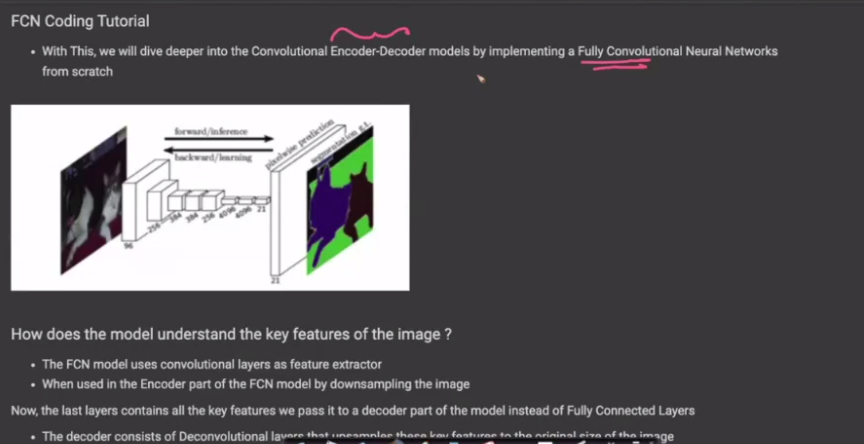

link - https://www.researchgate.net/search/publication?q=deep+learning

## Fully Convolutional Networks (FCN) in Computer Vision

Fully Convolutional Networks (FCNs) are a groundbreaking architecture in the field of computer vision, particularly for semantic segmentation tasks. Introduced by Long et al. in 2015, FCNs adapted traditional Convolutional Neural Networks (CNNs) from image classification to pixel-wise classification, enabling end-to-end learning for dense prediction without any fully connected layers.

### Key Idea:

The core idea behind FCNs is to transform classification networks (like AlexNet, VGG, or ResNet) into dense prediction networks. Traditional CNNs for classification typically end with fully connected layers that produce a single vector of class probabilities for the entire image. To perform semantic segmentation, where each pixel needs to be classified, FCNs replace these fully connected layers with convolutional layers.

### Architecture and Key Features:

1.  **All Convolutional Layers**: As the name suggests, FCNs consist entirely of convolutional layers. This means that the network can take an input image of arbitrary size and produce an output of corresponding spatial dimensions, with each output pixel corresponding to a pixel in the input image. This is a significant departure from traditional CNNs that require fixed-size inputs due to their fully connected layers.

2.  **Downsampling (Encoding Path)**: The initial part of an FCN often mirrors a standard CNN's encoding path, where convolutional and pooling layers progressively downsample the input image, extracting increasingly abstract and high-level features. This reduces the spatial resolution of the feature maps.

3.  **Upsampling (Decoding Path)**: To recover the spatial resolution for dense prediction, FCNs use upsampling techniques. The most common methods are:
    *   **Deconvolution (Transposed Convolution)**: This learns to upsample the feature maps back to the original image size.
    *   **Bilinear Interpolation**: A fixed upsampling method.

4.  **Skip Connections**: A crucial innovation in FCNs is the use of skip connections. After upsampling, the coarse, high-level feature maps (which carry strong semantic information but lack precise localization) are combined with finer, low-level feature maps (which retain spatial details) from the encoding path. This fusion helps to combine semantic information with precise spatial details, leading to more accurate segmentation boundaries.

5.  **Pixel-wise Classification**: The final layer of an FCN is typically a 1x1 convolutional layer followed by a softmax activation, which predicts a class label for each pixel in the upsampled feature map.

### Advantages of FCNs:

*   **End-to-End Learning**: FCNs can be trained end-to-end for semantic segmentation, simplifying the training process.
*   **Arbitrary Input Size**: The all-convolutional architecture allows FCNs to handle input images of any size, producing dense output maps of corresponding dimensions.
*   **High Performance**: FCNs significantly advanced the state-of-the-art in semantic segmentation, providing a strong foundation for many subsequent models.
*   **Foundation for Other Architectures**: The FCN architecture, particularly the encoder-decoder structure with skip connections, has inspired many other successful networks in computer vision, such as U-Net, SegNet, and DeepLab.

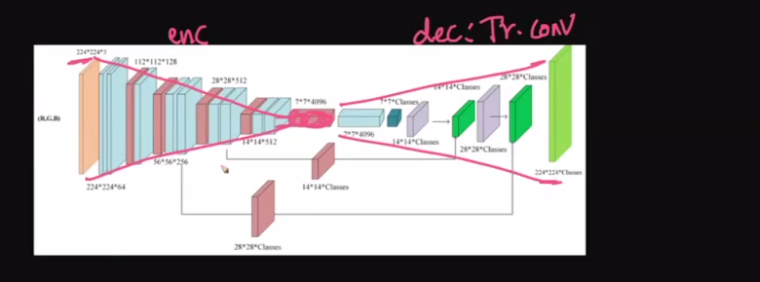

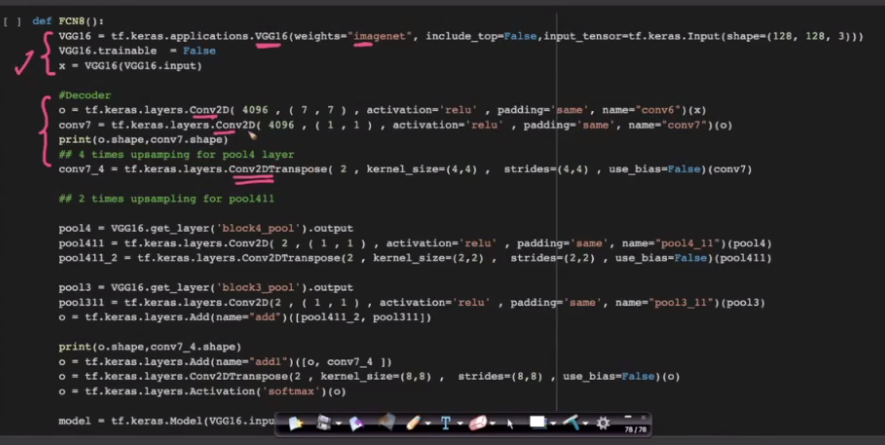

**U-NET**

original paper link - https://arxiv.org/pdf/1505.04597

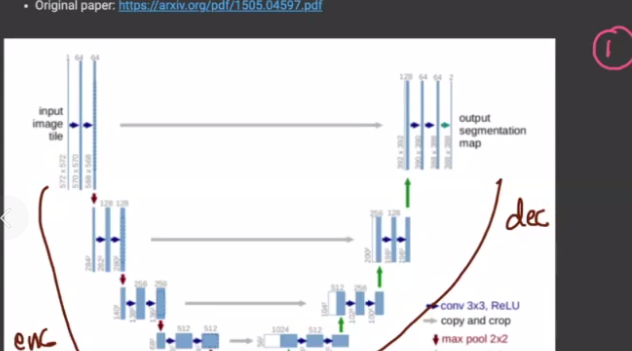

U-NET CODE 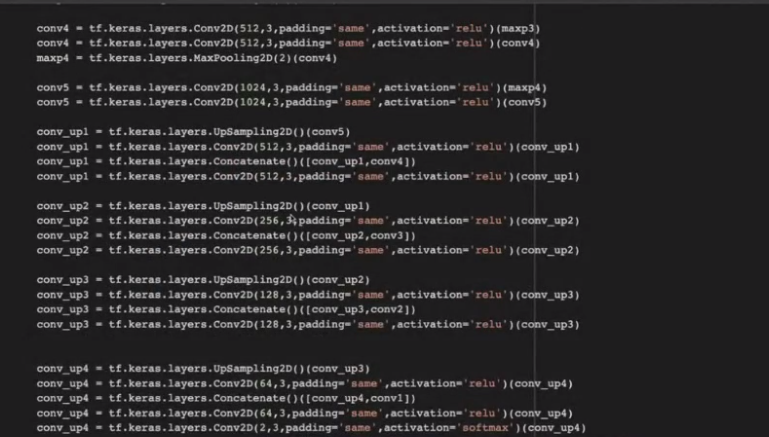

## U-Net Architecture in Computer Vision

U-Net is a convolutional network architecture developed for biomedical image segmentation, but it has since become widely popular and is used in various other semantic segmentation tasks. It was introduced by Ronneberger et al. in 2015 at the Computer Science Department of the University of Freiburg.

### Purpose and Key Idea:

U-Net is designed for **semantic segmentation**, which involves classifying each pixel of an image into a specific class. Its primary goal is to perform precise localization of features and provide accurate pixel-wise classification, even with a limited number of training images. The 'U' shape of its architecture gives it its name.

### U-Net Architecture Breakdown:

U-Net's architecture consists of two main parts:

1.  **Contracting Path (Encoder)**:
    *   This path is on the left side of the 'U' and is responsible for capturing context. It follows the typical architecture of a convolutional network.
    *   It consists of repeated application of two 3x3 convolutions (each followed by a ReLU activation function) and a 2x2 max pooling operation with stride 2 for downsampling.
    *   At each downsampling step, the number of feature channels is doubled. This allows the network to learn more abstract features as the spatial resolution decreases.

2.  **Expansive Path (Decoder)**:
    *   This path is on the right side of the 'U' and is responsible for enabling precise localization.
    *   It consists of an upsampling of the feature map (e.g., via transposed convolution), followed by a 2x2 convolution that halves the number of feature channels.
    *   **Concatenation with Skip Connections**: A key feature here is the concatenation of the upsampled feature map with the corresponding feature map from the contracting path (after cropping to ensure same size). This step is crucial because it allows the expansive path to combine high-resolution features from the contracting path with the upsampled information, leading to better detail preservation in the segmentation.
    *   After concatenation, two more 3x3 convolutions (each followed by a ReLU) are applied.
    *   At each upsampling step, the number of feature channels is halved.

3.  **Final Layer**:
    *   At the end of the expansive path, a 1x1 convolution is used to map each 64-component feature vector to the desired number of classes (e.g., 2 for binary segmentation: foreground/background).

### Advantages of U-Net:

*   **High Performance with Limited Data**: U-Net is particularly effective in scenarios with limited training data, a common challenge in medical imaging.
*   **Precise Localization**: The skip connections are vital for transferring fine-grained spatial information from the encoder to the decoder, enabling very accurate boundary detection.
*   **End-to-End Segmentation**: It can be trained end-to-end to produce a segmentation map directly from an input image.
*   **Versatility**: While originally designed for biomedical images, its architecture has been successfully applied to a wide range of segmentation tasks in various domains.